# Porte indisponível no SCR.data — PJ, Paraná

Quanto do crédito a empresas é concedido sem faturamento no cadastro, por tipo
de instituição, de janeiro/2019 a maio/2026.

**Fonte:** SCR.data, Banco Central do Brasil (licença ODbL).
**Decisões metodológicas:** ver `DECISOES.md` na raiz do repositório.

Caderno de exploração. As conclusões consolidadas vão para o README.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

PARQUET = '../data/processed/scrdata_pj_pr.parquet'
SEGMENTOS = ['Banco', 'Fintech', 'Instituição de pagamento']

## 1. Carregar e conferir o recorte

Antes de qualquer análise: o período está completo e o volume bate com o
esperado da rotina de ingestão?

In [10]:
df = pd.read_parquet(PARQUET)

print(f'linhas   : {len(df):,}')
print(
    f'período  : {df["data_base"].min():%m-%Y} a {df["data_base"].max():%m-%Y}')
print(f'meses    : {df["data_base"].nunique()}')
print(f'segmentos: {df["segmento"].nunique()}')

linhas   : 677,462
período  : 01-2019 a 05-2026
meses    : 89
segmentos: 8


## 2. Quem é quem no crédito do estado

Antes de comparar proporções entre segmentos, é preciso saber o tamanho de cada
um. Proporção sem volume ao lado engana.

In [11]:
total_mes = df.groupby('data_base', observed=True)['carteira_ativa'].sum()
por_seg = (df.groupby(['data_base', 'segmento'], observed=True)['carteira_ativa']
             .sum().unstack('segmento'))
share = por_seg.div(total_mes, axis=0)

resumo = pd.DataFrame({
    'carteira_mediana_R$': por_seg.median(),
    'fatia_mediana_%': (share.median() * 100).round(3),
    'fatia_max_%': (share.max() * 100).round(3),
})
resumo.sort_values('fatia_mediana_%', ascending=False)

,carteira_mediana_R$,fatia_mediana_%,fatia_max_%
segmento,,,
Banco,1.262740e+11,76.493,79.872
Cooperativa,1.888723e+10,11.687,16.865
Desenvolvimento/Fomento,1.351138e+10,8.252,16.516
Financeira,8.295703e+08,0.674,1.267
Arrendamento,5.894689e+08,0.480,0.718
Fintech,1.085598e+08,0.062,0.088
Instituição de pagamento,9.508374e+07,0.058,0.233
Outros,1.786579e+07,0.012,0.043


### Leitura

O Banco domina o crédito do estado. Fintech e Instituição de pagamento são
fatias muito pequenas do total.

**Consequência para a tese:** qualquer proporção alta encontrada nesses dois
segmentos é uma fatia grande de um todo pequeno. Isso não invalida o achado,
mas precisa ser dito junto com ele.

## 3. O teste decisivo — porte indisponível dentro de cada segmento

A hipótese original era que o banco tradicional não consegue enquadrar parte
relevante das pequenas empresas. Se for verdade, a fatia de porte indisponível
dentro do Banco tem que ser alta.

Medida em `carteira_ativa` — ver `DECISOES.md` para o porquê.

In [12]:
mes = df[df['data_base'] == df['data_base'].max()]

teste = (mes.groupby(['segmento', 'porte_indisponivel'], observed=True)['carteira_ativa']
            .sum().unstack('porte_indisponivel', fill_value=0))
teste.columns = ['porte_informado', 'porte_indisponivel']
teste['fatia_indisponivel_%'] = (
    teste['porte_indisponivel'] / teste.sum(axis=1) * 100).round(1)

teste.sort_values('fatia_indisponivel_%', ascending=False)

,porte_informado,porte_indisponivel,fatia_indisponivel_%
segmento,,,
Fintech,1.077368e+08,4.959428e+07,31.5
Instituição de pagamento,4.246690e+08,5.391124e+07,11.3
Financeira,2.430950e+09,2.479636e+08,9.3
Cooperativa,3.459085e+10,1.079796e+09,3.0
Arrendamento,1.383512e+09,2.492318e+07,1.8
Banco,1.510097e+11,2.811215e+09,1.8
Desenvolvimento/Fomento,1.722261e+10,6.097823e+07,0.4
Outros,1.341125e+07,1.397229e+04,0.1


### Leitura

A hipótese original **não se sustenta**: o banco sabe o faturamento de quase
tudo que empresta.

O que fica no lugar: o campo vazio descreve o **método de quem concedeu**, não a
empresa. A pergunta passa a ser quanto do crédito é concedido sem olhar
faturamento, e a que velocidade isso cresce.

## 4. A série mensal, sem filtro

Primeiro o gráfico cru, com tudo. Ele mostra o achado e também o problema.

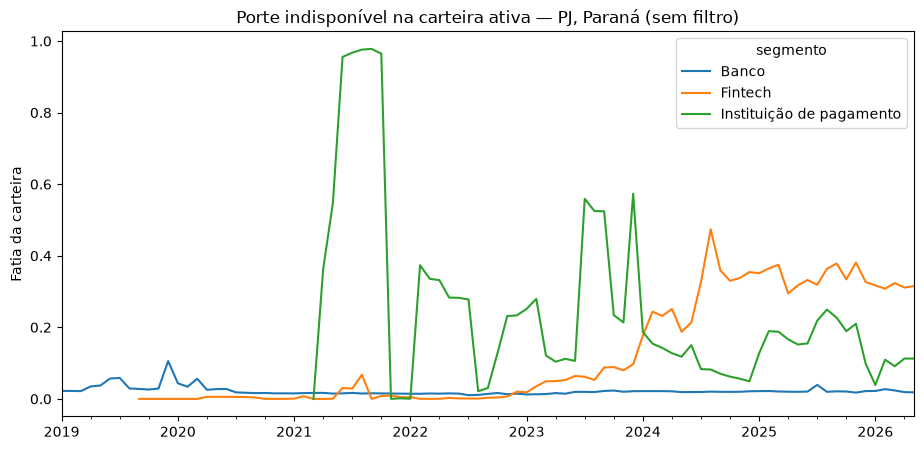

In [13]:
base = df[df['segmento'].isin(SEGMENTOS)]

# Denominator: all active credit per month and segment
total = base.groupby(['data_base', 'segmento'], observed=True)[
    'carteira_ativa'].sum()

# Numerator: the slice with no reported company size.
# reindex + fill_value=0 matters: a month with no such credit is a real zero,
# not a gap. Without it the line breaks and reads as missing data.
indisp = (base[base['porte_indisponivel']]
          .groupby(['data_base', 'segmento'], observed=True)['carteira_ativa'].sum()
          .reindex(total.index, fill_value=0))

serie = (indisp / total).unstack('segmento')

serie.plot(figsize=(11, 5))
plt.title('Porte indisponível na carteira ativa — PJ, Paraná (sem filtro)')
plt.ylabel('Fatia da carteira')
plt.xlabel('')
plt.show()

### Leitura

Duas linhas se comportam e uma não.

- **Banco**: plano em torno de 2% por sete anos. Atravessa pandemia e ciclo de
  juros sem mudar. É um controle quase perfeito.
- **Fintech**: sai de perto de zero e sobe de forma sustentada. Tendência, não
  oscilação.
- **Instituição de pagamento**: vai a 97%, cai a zero, volta a 37%. Isso não é
  comportamento econômico.

O trecho instável da linha verde está no início da série, quando o segmento mal
existia no estado. Proporção calculada sobre carteira minúscula se move
inteira com pouquíssimos contratos.

## 5. Diagnóstico: o que torna uma proporção instável

Um piso baseado em participação de mercado **não serve** — a fintech é ainda
menor que a instituição de pagamento, então qualquer corte por tamanho relativo
derrubaria os dois.

O critério tem que mirar a estabilidade em si: quanto **um único contrato**
desloca a proporção naquele mês. Onde esse deslocamento for grande, a linha não
é confiável.

In [14]:
ok = base[~base['operacoes_suprimidas']]

diag = ok.groupby(['data_base', 'segmento'], observed=True).agg(
    carteira=('carteira_ativa', 'sum'),
    operacoes=('numero_de_operacoes', 'sum'))

# How much one single contract moves the ratio, in percentage points
diag['impacto_1_contrato_pp'] = 100 / diag['operacoes']

diag.groupby('segmento', observed=True)[
    'impacto_1_contrato_pp'].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
segmento,,,,,,,,
Banco,89.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Fintech,80.0,0.880,2.412,0.007,0.016,0.029,0.221,14.286
Instituição de pagamento,63.0,0.032,0.176,0.001,0.001,0.002,0.005,1.389


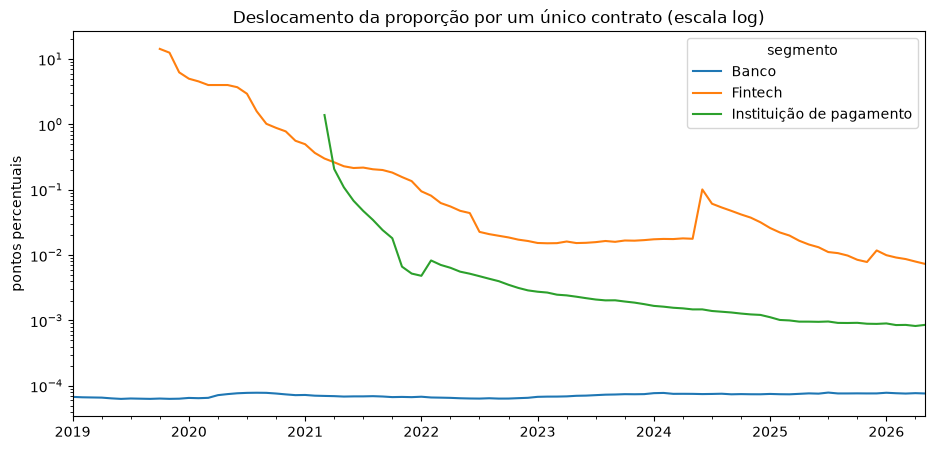

In [15]:
impacto = diag['impacto_1_contrato_pp'].unstack('segmento')

impacto.plot(figsize=(11, 5), logy=True)
plt.title('Deslocamento da proporção por um único contrato (escala log)')
plt.ylabel('pontos percentuais')
plt.xlabel('')
plt.show()

### Decisão pendente

Definir o teto de `impacto_1_contrato_pp` acima do qual o mês é considerado
instável e sai do gráfico.

**Regra:** o teto vale para todos os segmentos igualmente. Se derrubar meses da
fintech, esses meses saem também.

Registrar em `DECISOES.md` o valor escolhido e o motivo.

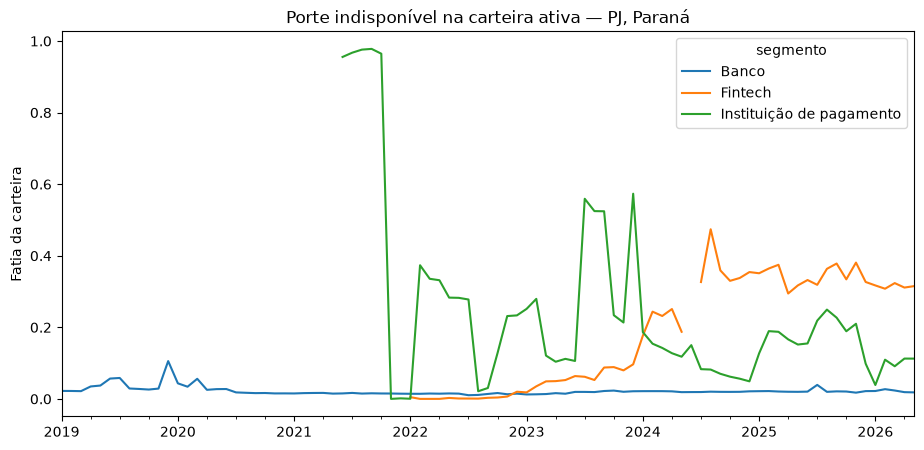

meses mantidos por segmento:
segmento
Banco                       89
Fintech                     52
Instituição de pagamento    60
dtype: int64


In [28]:
TETO_PP = 0.1  # definir a partir do diagnóstico acima

if TETO_PP is not None:
    elegivel = impacto <= TETO_PP
    serie_filtrada = serie.where(elegivel[serie.columns])

    serie_filtrada.plot(figsize=(11, 5))
    plt.title('Porte indisponível na carteira ativa — PJ, Paraná')
    plt.ylabel('Fatia da carteira')
    plt.xlabel('')
    plt.show()

    print('meses mantidos por segmento:')
    print(elegivel[serie.columns].sum())

## 6. Próximos passos

- Fechar o teto de estabilidade e registrar a decisão.
- Investigar as quebras na contagem de linhas em jun/2024 e jul/2025 — se forem
  mudança de metodologia, a série tem emenda e a tendência precisa de ressalva.
- Descer para sub-região do Paraná, que exige o conjunto separado do Banco
  Central.
- Abrir por setor: onde o método sem faturamento cresce mais rápido.